In [2]:
import torch
torch.cuda.empty_cache()
import torch.nn as nn
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

In [3]:
class ContractiveAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(ContractiveAutoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size),
            nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(output_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, input_size),
            nn.Sigmoid()
        )
        self.criterion = nn.MSELoss()
        self.beta = 1e-4

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

    def loss_function(self, x, decoded, encoded):
        mse_loss = self.criterion(decoded, x)
        jacobian = torch.autograd.functional.jacobian(lambda x: encoded, x)
        frobenius_norm = torch.norm(jacobian, p='fro')
        contraction_loss = torch.mean(frobenius_norm)
        total_loss = mse_loss + (self.beta * contraction_loss)
        return total_loss

In [4]:
# Set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
# Hyperparameters
input_size = 784  # MNIST images are 28x28 pixels
hidden_size = 128
output_size = 64
learning_rate = 0.001
num_epochs = 10
batch_size = 64


In [6]:
# Load MNIST dataset
train_dataset = MNIST(root="./data", train=True, transform=ToTensor(), download=True)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

In [7]:
# Initialize the autoencoder
autoencoder = ContractiveAutoencoder(input_size, hidden_size, output_size).to(device)

# Define the optimizer
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=learning_rate)

In [8]:
# Training loop
total_steps = len(train_dataloader)
for epoch in range(num_epochs):
    for i, (images, _) in enumerate(train_dataloader):
        # Move images to the device
        images = images.to(device)
        inputs = images.view(images.size(0), -1)

        # Forward pass
        encoded, decoded = autoencoder(inputs)

        # Compute the loss
        loss = autoencoder.loss_function(inputs, decoded, encoded)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i + 1) % 50 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_steps}], Loss: {loss.item():.4f}")

Epoch [1/10], Step [50/938], Loss: 0.0729
Epoch [1/10], Step [100/938], Loss: 0.0654
Epoch [1/10], Step [150/938], Loss: 0.0568
Epoch [1/10], Step [200/938], Loss: 0.0462
Epoch [1/10], Step [250/938], Loss: 0.0413
Epoch [1/10], Step [300/938], Loss: 0.0420
Epoch [1/10], Step [350/938], Loss: 0.0331
Epoch [1/10], Step [400/938], Loss: 0.0332
Epoch [1/10], Step [450/938], Loss: 0.0280
Epoch [1/10], Step [500/938], Loss: 0.0297
Epoch [1/10], Step [550/938], Loss: 0.0287
Epoch [1/10], Step [600/938], Loss: 0.0280
Epoch [1/10], Step [650/938], Loss: 0.0225
Epoch [1/10], Step [700/938], Loss: 0.0225
Epoch [1/10], Step [750/938], Loss: 0.0229
Epoch [1/10], Step [800/938], Loss: 0.0247
Epoch [1/10], Step [850/938], Loss: 0.0227
Epoch [1/10], Step [900/938], Loss: 0.0215
Epoch [2/10], Step [50/938], Loss: 0.0213
Epoch [2/10], Step [100/938], Loss: 0.0193
Epoch [2/10], Step [150/938], Loss: 0.0208
Epoch [2/10], Step [200/938], Loss: 0.0182
Epoch [2/10], Step [250/938], Loss: 0.0179
Epoch [2/10],

In [9]:
torch.save(autoencoder, "../saved_models/cae_minst.pt")

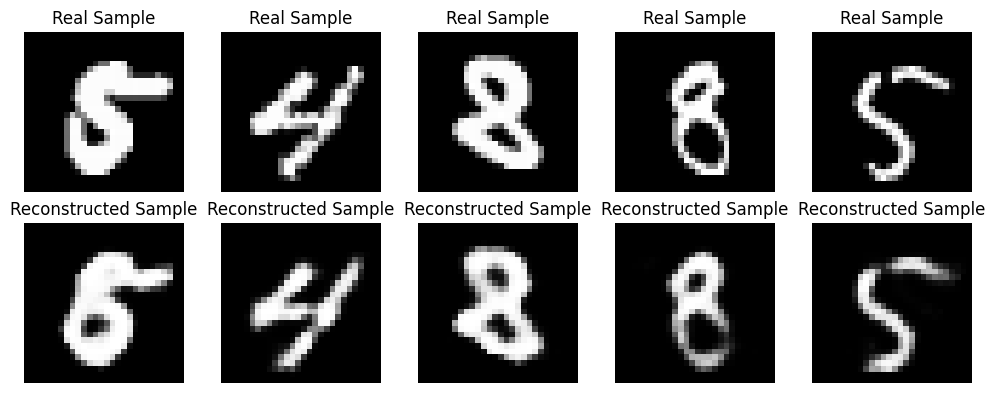

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Select a few images from the dataset
num_samples = 5
# sample_images = iter(train_dataloader).next()[0][:num_samples]
sample_images = next(iter(train_dataloader))[0][:num_samples]
sample_images = sample_images.to(device)
sample_inputs = sample_images.view(sample_images.size(0), -1)

# Pass the sample images through the autoencoder
with torch.no_grad():
    encoded_samples, decoded_samples = autoencoder(sample_inputs)

# Move the sample images and their reconstructions to CPU
sample_images = sample_images.cpu().numpy()
decoded_samples = decoded_samples.cpu().numpy()

# Reshape the images
sample_images = np.reshape(sample_images, (num_samples, 28, 28))
decoded_samples = np.reshape(decoded_samples, (num_samples, 28, 28))

# Display the sample images and their reconstructions
fig, axes = plt.subplots(nrows=2, ncols=num_samples, figsize=(10, 4))

for i in range(num_samples):
    axes[0, i].imshow(sample_images[i], cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title('Real Sample')

    axes[1, i].imshow(decoded_samples[i], cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title('Reconstructed Sample')

plt.tight_layout()
plt.show()


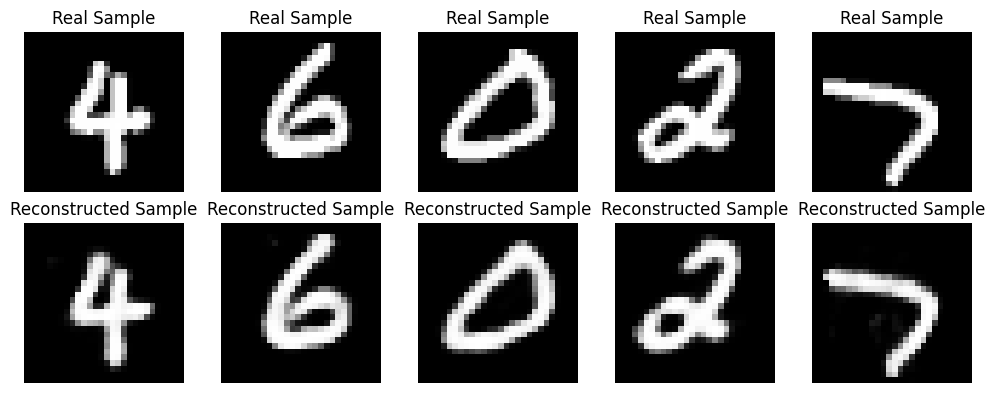